In [1]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.models as models

Set device

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Set random seeds for reproducibility

In [4]:
torch.manual_seed(42)
np.random.seed(42)

============================================================================<br>
Configuration<br>
============================================================================

In [5]:
DATA_PATH = '/kaggle/input/odir-data/data.xlsx'
IMAGE_DIR = '/kaggle/input/odir-data/crop_training_images'
IMAGE_SIZE = 128
BATCH_SIZE = 16
NUM_EPOCHS = 20
LEARNING_RATE = 0.0001

Target columns

In [6]:
TARGET_COLS = ['N', 'D', 'G', 'C', 'A', 'H', 'M', 'O']

============================================================================<br>
Load and Preprocess Data<br>
============================================================================

In [7]:
print("Loading data...")
df = pd.read_excel(DATA_PATH)
print(f"Dataset shape: {df.shape}")

Loading data...
Dataset shape: (3500, 15)


Check for valid image paths

In [8]:
id_col = 'ID'
age_col = 'Patient Age'
gender_col = 'Patient Sex'

In [9]:
valid_samples = []
for idx, row in df.iterrows():
    sample_id = row[id_col]
    left_path = os.path.join(IMAGE_DIR, f"{sample_id}_left.jpg")
    right_path = os.path.join(IMAGE_DIR, f"{sample_id}_right.jpg")
    
    if os.path.exists(left_path) and os.path.exists(right_path):
        valid_samples.append(idx)

In [10]:
df_filtered = df.loc[valid_samples].reset_index(drop=True)
print(f"Valid samples with both images: {len(df_filtered)}")

Valid samples with both images: 3500


Encode gender and normalize age

In [11]:
df_filtered['gender_encoded'] = df_filtered[gender_col].map({'M': 0, 'F': 1, 'Male': 0, 'Female': 1})
df_filtered['gender_encoded'].fillna(0, inplace=True)
df_filtered[age_col].fillna(df_filtered[age_col].median(), inplace=True)

/tmp/ipykernel_20/2580565324.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_filtered['gender_encoded'].fillna(0, inplace=True)
/tmp/ipykernel_20/2580565324.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try

In [12]:
scaler = StandardScaler()
df_filtered['age_normalized'] = scaler.fit_transform(df_filtered[[age_col]])

============================================================================<br>
Split Data: 70% train, 20% validation, 10% test<br>
============================================================================

In [13]:
print("\nSplitting dataset into train/val/test (70/20/10)...")
train_df, temp_df = train_test_split(
    df_filtered, 
    test_size=0.3, 
    random_state=42,
    stratify=df_filtered[TARGET_COLS[0]] if TARGET_COLS[0] in df_filtered.columns else None
)


Splitting dataset into train/val/test (70/20/10)...


In [14]:
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.333,  # 10% of total (0.333 of 30%)
    random_state=42,
    stratify=temp_df[TARGET_COLS[0]] if TARGET_COLS[0] in temp_df.columns else None
)

In [15]:
print(f"Training samples: {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

Training samples: 2450
Validation samples: 700
Test samples: 350


============================================================================<br>
Dataset Class<br>
============================================================================

In [16]:
class MultimodalFundusDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None, num_labels=8):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform
        self.num_labels = num_labels
        
    def __len__(self):
        return len(self.df)
    
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        sample_id = row[id_col]
        
        # Load images
        left_img_path = os.path.join(self.image_dir, f"{sample_id}_left.jpg")
        right_img_path = os.path.join(self.image_dir, f"{sample_id}_right.jpg")
        
        left_img = Image.open(left_img_path).convert('RGB')
        right_img = Image.open(right_img_path).convert('RGB')
        
        # Apply transforms
        if self.transform:
            left_img = self.transform(left_img)
            right_img = self.transform(right_img)
        
        # Get tabular features
        age = row['age_normalized']
        gender = row['gender_encoded']
        tabular_data = torch.tensor([age, gender], dtype=torch.float32)
        
        # Get labels
        labels = torch.zeros(self.num_labels, dtype=torch.float32)
        for i, col in enumerate(TARGET_COLS[:self.num_labels]):
            if col in row:
                labels[i] = float(row[col])
        
        return left_img, right_img, tabular_data, labels

============================================================================<br>
Data Transforms<br>
============================================================================

In [17]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [18]:
val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

Create datasets

In [19]:
train_dataset = MultimodalFundusDataset(train_df, IMAGE_DIR, train_transform, len(TARGET_COLS))
val_dataset = MultimodalFundusDataset(val_df, IMAGE_DIR, val_transform, len(TARGET_COLS))
test_dataset = MultimodalFundusDataset(test_df, IMAGE_DIR, val_transform, len(TARGET_COLS))

Create data loaders

In [20]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4, pin_memory=True)

In [21]:
print(f"\nNumber of training batches: {len(train_loader)}")
print(f"Number of validation batches: {len(val_loader)}")
print(f"Number of test batches: {len(test_loader)}")


Number of training batches: 154
Number of validation batches: 44
Number of test batches: 22


============================================================================<br>
Model Architecture<br>
============================================================================

In [22]:
class LightweightCNN(nn.Module):
    def __init__(self):
        super(LightweightCNN, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1: 3 -> 32
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 2: 32 -> 64
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 3: 64 -> 128
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),
            
            # Block 4: 128 -> 128
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        
    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return x

In [23]:
class MultimodalFundusModel(nn.Module):
    def __init__(self, num_classes=8):
        super(MultimodalFundusModel, self).__init__()
        
        # Image encoder
        self.image_encoder = LightweightCNN()
        image_feature_dim = 128
        
        # Tabular encoder
        tabular_input_dim = 2
        tabular_hidden_dim = 32
        
        self.tabular_encoder = nn.Sequential(
            nn.Linear(tabular_input_dim, 16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, tabular_hidden_dim),
            nn.ReLU()
        )
        
        # Fusion and classification
        fused_dim = (image_feature_dim * 2) + tabular_hidden_dim
        
        self.classifier = nn.Sequential(
            nn.Linear(fused_dim, 128),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(64, num_classes),
            nn.Sigmoid()
        )
    
    def forward(self, left_img, right_img, tabular_data):
        left_features = self.image_encoder(left_img)
        right_features = self.image_encoder(right_img)
        tabular_features = self.tabular_encoder(tabular_data)
        
        fused_features = torch.cat([left_features, right_features, tabular_features], dim=1)
        output = self.classifier(fused_features)
        
        return output

Initialize model

In [24]:
model = MultimodalFundusModel(num_classes=len(TARGET_COLS))
model = model.to(device)

In [25]:
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")


Total parameters: 287,896


============================================================================<br>
Loss and Optimizer<br>
============================================================================

In [26]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

============================================================================<br>
Hamming Accuracy Function<br>
============================================================================

In [27]:
def hamming_accuracy(y_true, y_pred, threshold=0.5):
    """
    Calculate Hamming Accuracy (exact match ratio across all labels).
    Hamming Accuracy = (# of correctly predicted labels) / (total # of labels)
    """
    y_pred_binary = (y_pred > threshold).float()
    correct = (y_pred_binary == y_true).float()
    hamming_acc = correct.mean().item()
    return hamming_acc

============================================================================<br>
Training Functions<br>
============================================================================

In [28]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_labels = []
    all_predictions = []
    
    for batch_idx, (left_img, right_img, tabular_data, labels) in enumerate(loader):
        left_img = left_img.to(device)
        right_img = right_img.to(device)
        tabular_data = tabular_data.to(device)
        labels = labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(left_img, right_img, tabular_data)
        loss = criterion(outputs, labels)
        
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        all_labels.append(labels.cpu())
        all_predictions.append(outputs.detach().cpu())
        
        if (batch_idx + 1) % 10 == 0:
            print(f"  Batch [{batch_idx+1}/{len(loader)}], Loss: {loss.item():.4f}")
    
    avg_loss = running_loss / len(loader)
    
    # Calculate training accuracy
    all_labels = torch.cat(all_labels, dim=0)
    all_predictions = torch.cat(all_predictions, dim=0)
    train_acc = hamming_accuracy(all_labels, all_predictions)
    
    return avg_loss, train_acc

In [29]:
def validate_epoch(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_labels = []
    all_predictions = []
    
    with torch.no_grad():
        for left_img, right_img, tabular_data, labels in loader:
            left_img = left_img.to(device)
            right_img = right_img.to(device)
            tabular_data = tabular_data.to(device)
            labels = labels.to(device)
            
            outputs = model(left_img, right_img, tabular_data)
            loss = criterion(outputs, labels)
            running_loss += loss.item()
            
            all_labels.append(labels.cpu())
            all_predictions.append(outputs.cpu())
    
    avg_loss = running_loss / len(loader)
    
    # Calculate validation accuracy
    all_labels = torch.cat(all_labels, dim=0)
    all_predictions = torch.cat(all_predictions, dim=0)
    val_acc = hamming_accuracy(all_labels, all_predictions)
    
    return avg_loss, val_acc

============================================================================<br>
Training Loop<br>
============================================================================

In [30]:
print("\nStarting training...")
print("=" * 70)


Starting training...


In [31]:
train_losses = []
val_losses = []
train_accs = []
val_accs = []
best_val_loss = float('inf')

In [32]:
for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch [{epoch+1}/{NUM_EPOCHS}]")
    print("-" * 70)
    
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate_epoch(model, val_loader, criterion, device)
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    print(f"\n  Train Loss: {train_loss:.4f}, Train Accuracy: {train_acc:.4f}")
    print(f"  Val Loss:   {val_loss:.4f}, Val Accuracy:   {val_acc:.4f}")
    
    scheduler.step(val_loss)
    
    # Save best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'train_acc': train_acc,
            'val_acc': val_acc
        }, 'best_multimodal_model.pth')
        print("  âœ“ Best model saved!")


Epoch [1/20]
----------------------------------------------------------------------
  Batch [10/154], Loss: 0.6816
  Batch [20/154], Loss: 0.6600
  Batch [30/154], Loss: 0.6457
  Batch [40/154], Loss: 0.6141
  Batch [50/154], Loss: 0.6070
  Batch [60/154], Loss: 0.6080
  Batch [70/154], Loss: 0.5706
  Batch [80/154], Loss: 0.5144
  Batch [90/154], Loss: 0.5130
  Batch [100/154], Loss: 0.4912
  Batch [110/154], Loss: 0.4893
  Batch [120/154], Loss: 0.4251
  Batch [130/154], Loss: 0.4393
  Batch [140/154], Loss: 0.3866
  Batch [150/154], Loss: 0.3881

  Train Loss: 0.5451, Train Accuracy: 0.8008
  Val Loss:   0.3707, Val Accuracy:   0.8523
  âœ“ Best model saved!

Epoch [2/20]
----------------------------------------------------------------------
  Batch [10/154], Loss: 0.3821
  Batch [20/154], Loss: 0.3627
  Batch [30/154], Loss: 0.4050
  Batch [40/154], Loss: 0.3731
  Batch [50/154], Loss: 0.4038
  Batch [60/154], Loss: 0.3481
  Batch [70/154], Loss: 0.4107
  Batch [80/154], Loss: 0.4

In [33]:
print("\n" + "=" * 70)
print("Training completed!")


Training completed!


============================================================================<br>
Plot Training History<br>
============================================================================

In [34]:
print("\nPlotting training history...")


Plotting training history...


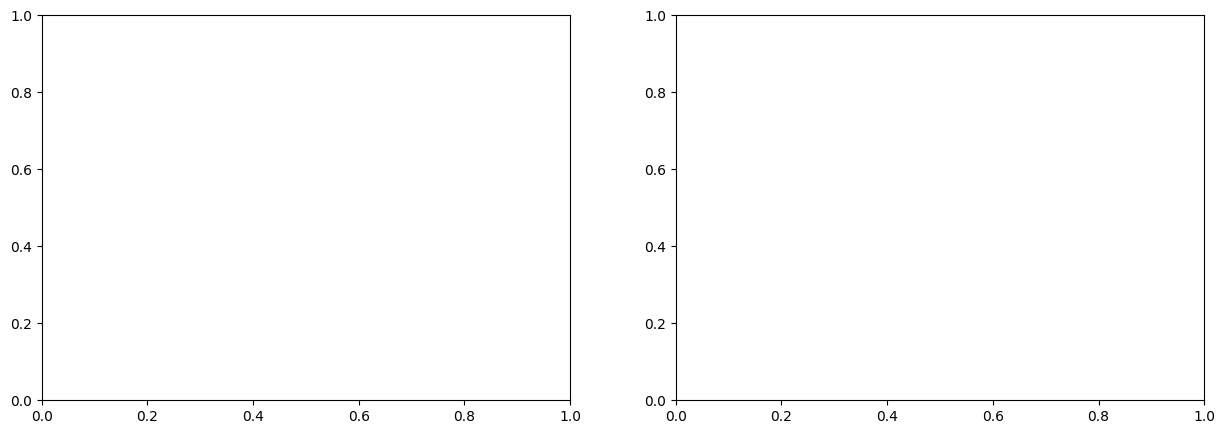

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

Plot Loss

In [36]:
axes[0].plot(range(1, NUM_EPOCHS + 1), train_losses, 'b-', label='Train Loss')
axes[0].plot(range(1, NUM_EPOCHS + 1), val_losses, 'r-', label='Val Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training and Validation Loss')
axes[0].legend()
axes[0].grid(True)

Plot Accuracy

In [37]:
axes[1].plot(range(1, NUM_EPOCHS + 1), train_accs, 'b-', label='Train Accuracy')
axes[1].plot(range(1, NUM_EPOCHS + 1), val_accs, 'r-', label='Val Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Hamming Accuracy')
axes[1].set_title('Training and Validation Accuracy')
axes[1].legend()
axes[1].grid(True)

In [38]:
plt.tight_layout()
plt.savefig('training_history.png', dpi=150)
plt.show()
print("Training history plot saved as 'training_history.png'")

<Figure size 640x480 with 0 Axes>

Training history plot saved as 'training_history.png'


============================================================================<br>
Evaluation on Test Set<br>
============================================================================

In [39]:
print("\nEvaluating on test set...")


Evaluating on test set...


Load best model

In [40]:
checkpoint = torch.load('best_multimodal_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']}")

Loaded best model from epoch 20


Evaluate

In [41]:
model.eval()
all_predictions = []
all_labels = []

In [42]:
with torch.no_grad():
    for left_img, right_img, tabular_data, labels in test_loader:
        left_img = left_img.to(device)
        right_img = right_img.to(device)
        tabular_data = tabular_data.to(device)
        
        outputs = model(left_img, right_img, tabular_data)
        
        all_predictions.append(outputs.cpu().numpy())
        all_labels.append(labels.cpu().numpy())

Concatenate all batches

In [43]:
predictions = np.vstack(all_predictions)
ground_truth = np.vstack(all_labels)

Calculate Hamming Accuracy per class and overall

In [44]:
print("\n" + "=" * 70)
print("Test Set Evaluation Results (Hamming Accuracy):")
print("=" * 70)


Test Set Evaluation Results (Hamming Accuracy):


In [45]:
pred_binary = (predictions > 0.5).astype(int)

In [46]:
for i, label_name in enumerate(TARGET_COLS):
    correct = (pred_binary[:, i] == ground_truth[:, i]).sum()
    total = len(ground_truth)
    class_acc = correct / total
    print(f"{label_name:15s} - Hamming Accuracy: {class_acc:.4f}")

N               - Hamming Accuracy: 0.6743
D               - Hamming Accuracy: 0.6886
G               - Hamming Accuracy: 0.9229
C               - Hamming Accuracy: 0.9486
A               - Hamming Accuracy: 0.9600
H               - Hamming Accuracy: 0.9486
M               - Hamming Accuracy: 0.9486
O               - Hamming Accuracy: 0.7314


Overall Hamming Accuracy

In [47]:
overall_correct = (pred_binary == ground_truth).sum()
overall_total = ground_truth.size
overall_hamming_acc = overall_correct / overall_total

In [48]:
print("\n" + "-" * 70)
print(f"Overall Hamming Accuracy: {overall_hamming_acc:.4f}")
print("=" * 70)


----------------------------------------------------------------------
Overall Hamming Accuracy: 0.8529


In [49]:
print("\nâœ“ All done! Check 'training_history.png' for visualizations.")


âœ“ All done! Check 'training_history.png' for visualizations.
